# Microsoft LayoutLMv3 Medical Document Classifier
This notebook implements a complete document classification pipeline using `microsoft/layoutlmv3-base` combining text, layout coordinates, and visual features.

### Training Strategy:
- **Tesseract OCR Pre-caching**: Words and normalized coordinates are cached in memory to avoid running Tesseract multiple times during training.
- **Feature Caching**: Since the LayoutLMv3 backbone is frozen, we pre-calculate sequence representation (CLS token) features. This makes CPU training finish in seconds!
- **Class-Weighted Cross-Entropy Loss**: Corrects class imbalance to ensure minority report types (e.g. CRP, Microbiology) are classified correctly.


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import sys
import time
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pytesseract
from transformers import AutoProcessor, LayoutLMv3ForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Configure Tesseract path
TESS_PATH = r"C:\Program Files\Tesseract-OCR\tesseract.exe"
if os.path.exists(TESS_PATH):
    pytesseract.pytesseract.tesseract_cmd = TESS_PATH

# Set UTF-8 encoding wrapper for console
import io
sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8') if hasattr(sys.stdout, 'buffer') else sys.stdout
sys.stderr = io.TextIOWrapper(sys.stderr.buffer, encoding='utf-8') if hasattr(sys.stderr, 'buffer') else sys.stderr

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


PyTorch Version: 2.12.0+cpu
CUDA Available: False
Using device: cpu


## Data Gathering and Preprocessing
We locate all report images from `datasets/lab_reports/` and encode target classes.


In [2]:
DATASET_PATH = "../datasets/lab_reports"
MODEL_SAVE_DIR = "../models/layoutlmv3_classifier"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
CACHE_PATH = os.path.join(MODEL_SAVE_DIR, "ocr_cache.pkl")

TARGET_CLASSES = ["cbc", "crp", "lft", "kidney_function_test", "urine", "microbiology", "haematology"]

rows = []
for cls in TARGET_CLASSES:
    folder = os.path.join(DATASET_PATH, cls)
    if not os.path.exists(folder):
        continue
    for f in os.listdir(folder):
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
            rows.append({
                'image_path': os.path.join(folder, f),
                'image_name': f,
                'label': cls
            })

df = pd.DataFrame(rows)
print(f"Total report images found: {df.shape[0]}")
print(df['label'].value_counts())

# Encode labels
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

label_encoder_path = os.path.join(MODEL_SAVE_DIR, "label_encoder.pkl")
with open(label_encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"Label encoder saved to: {label_encoder_path}")


Total report images found: 256
label
cbc                     62
haematology             48
lft                     40
kidney_function_test    31
urine                   29
microbiology            27
crp                     19
Name: count, dtype: int64
Label encoder saved to: ../models/layoutlmv3_classifier\label_encoder.pkl


## OCR Bounding Box & Word Extraction
Define a helper function to run Tesseract and cache word/coordinates in pickle format.


In [3]:
def pre_cache_ocr(df):
    if os.path.exists(CACHE_PATH):
        print(f"Loading pre-cached OCR data from {CACHE_PATH}...")
        with open(CACHE_PATH, 'rb') as f:
            return pickle.load(f)
            
    print("Pre-extracting OCR data for all images using Tesseract...")
    cache = {}
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="OCR Pre-extraction"):
        img_path = row['image_path']
        try:
            img = Image.open(img_path).convert("RGB")
            width, height = img.size
            ocr_data = pytesseract.image_to_data(img, output_type=pytesseract.Output.DICT)
            
            words = []
            boxes = []
            for i in range(len(ocr_data['text'])):
                word = ocr_data['text'][i].strip()
                if word != "":
                    words.append(word)
                    x, y, w, h = ocr_data['left'][i], ocr_data['top'][i], ocr_data['width'][i], ocr_data['height'][i]
                    
                    x0 = max(0, min(1000, int(x / width * 1000)))
                    y0 = max(0, min(1000, int(y / height * 1000)))
                    x1 = max(0, min(1000, int((x + w) / width * 1000)))
                    y1 = max(0, min(1000, int((y + h) / height * 1000)))
                    
                    boxes.append([x0, y0, x1, y1])
            if not words:
                words = ["missing"]
                boxes = [[0, 0, 0, 0]]
            cache[img_path] = {
                'words': words,
                'boxes': boxes
            }
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            cache[img_path] = {
                'words': ["missing"],
                'boxes': [[0, 0, 0, 0]]
            }
            
    print(f"Saving pre-cached OCR data to {CACHE_PATH}...")
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(cache, f)
    return cache

ocr_cache = pre_cache_ocr(df)


Loading pre-cached OCR data from ../models/layoutlmv3_classifier\ocr_cache.pkl...


## PyTorch Dataset & DataLoader
Define `LayoutLMv3MedicalDataset` which prepares the multimodal inputs.


In [4]:
class LayoutLMv3MedicalDataset(Dataset):
    def __init__(self, df, processor, ocr_cache, max_len=512):
        self.df = df
        self.processor = processor
        self.ocr_cache = ocr_cache
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        label = row['label_encoded']
        
        if image_path in self.ocr_cache:
            words = self.ocr_cache[image_path]['words']
            boxes = self.ocr_cache[image_path]['boxes']
        else:
            words = ["missing"]
            boxes = [[0, 0, 0, 0]]
            
        img = Image.open(image_path).convert("RGB")
        
        encoding = self.processor(
            img,
            text=words,
            boxes=boxes,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'bbox': encoding['bbox'].squeeze(0),
            'pixel_values': encoding['pixel_values'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

class FeatureDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels
        
    def __len__(self):
        return len(self.features)
        
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

print("Loading microsoft/layoutlmv3-base Processor...")
processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)
processor.save_pretrained(MODEL_SAVE_DIR)


Loading microsoft/layoutlmv3-base Processor...


['../models/layoutlmv3_classifier\\processor_config.json']

## Model Initialization & Caching Setup
Initialize LayoutLMv3, freeze the backbone, and define classification feature extraction.


In [5]:
print("Loading LayoutLMv3 model...")
model = LayoutLMv3ForSequenceClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    num_labels=len(TARGET_CLASSES)
)

# Freeze lower backbone layers
for param in model.layoutlmv3.parameters():
    param.requires_grad = False

# Classifier remains trainable
for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)


Loading LayoutLMv3 model...


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForSequenceClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                        | Status  | 
---------------------------+---------+-
classifier.dense.weight    | MISSING | 
classifier.dense.bias      | MISSING | 
classifier.out_proj.bias   | MISSING | 
classifier.out_proj.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Model Training Loop & Evaluation
We set `RUN_FULL_TRAINING = True` to perform feature extraction and run classifier head training.


In [6]:
RUN_FULL_TRAINING = True

train_df, val_df = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42, 
    stratify=df['label_encoded']
)

if not RUN_FULL_TRAINING:
    print("Quick local verification mode...")
else:
    print(f"Train size: {len(train_df)}, Val size: {len(val_df)}")
    
    # Feature Extraction
    print("\nPre-extracting LayoutLMv3 CLS features to speed up CPU training...")
    def extract_features(df_subset, desc):
        dataset = LayoutLMv3MedicalDataset(df_subset, processor, ocr_cache)
        loader = DataLoader(dataset, batch_size=4, shuffle=False)
        all_cls_features = []
        all_labels = []
        model.eval()
        with torch.no_grad():
            for batch in tqdm(loader, desc=desc):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                bbox = batch['bbox'].to(device)
                pixel_values = batch['pixel_values'].to(device)
                labels = batch['labels']
                
                outputs = model.layoutlmv3(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    bbox=bbox,
                    pixel_values=pixel_values
                )
                cls_feat = outputs[0][:, 0, :].cpu()
                all_cls_features.append(cls_feat)
                all_labels.append(labels)
        return torch.cat(all_cls_features, dim=0), torch.cat(all_labels, dim=0)

    train_features, train_labels = extract_features(train_df, "Train Feature Extraction")
    val_features, val_labels = extract_features(val_df, "Val Feature Extraction")
    
    train_loader = DataLoader(FeatureDataset(train_features, train_labels), batch_size=8, shuffle=True)
    val_loader = DataLoader(FeatureDataset(val_features, val_labels), batch_size=8)
    
    # Weights to handle class imbalance
    class_counts = df['label_encoded'].value_counts().sort_index().values
    total_samples = len(df)
    num_classes = len(class_counts)
    class_weights = total_samples / (num_classes * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = AdamW(model.classifier.parameters(), lr=2e-4, weight_decay=0.05)
    
    best_val_loss = float('inf')
    patience = 8
    patience_counter = 0
    epochs = 40
    
    print("\n--- Training Classifier Head ---")
    for epoch in range(1, epochs + 1):
        model.classifier.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_features, batch_labels in train_loader:
            batch_features = batch_features.unsqueeze(1).to(device)
            batch_labels = batch_labels.to(device)
            
            optimizer.zero_grad()
            logits = model.classifier(batch_features).squeeze(1)
            loss = criterion(logits, batch_labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * len(batch_labels)
            preds = torch.argmax(logits, dim=1)
            train_correct += (preds == batch_labels).sum().item()
            train_total += len(batch_labels)
            
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        model.classifier.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch_features, batch_labels in val_loader:
                batch_features = batch_features.unsqueeze(1).to(device)
                batch_labels = batch_labels.to(device)
                logits = model.classifier(batch_features).squeeze(1)
                loss = criterion(logits, batch_labels)
                
                val_loss += loss.item() * len(batch_labels)
                preds = torch.argmax(logits, dim=1)
                val_correct += (preds == batch_labels).sum().item()
                val_total += len(batch_labels)
                
        val_loss /= val_total
        val_acc = val_correct / val_total
        
        print(f"Epoch {epoch:02d}: Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            model.save_pretrained(MODEL_SAVE_DIR)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}!")
                break


Train size: 204, Val size: 52

Pre-extracting LayoutLMv3 CLS features to speed up CPU training...


Train Feature Extraction:   0%|          | 0/51 [00:00<?, ?it/s]

Train Feature Extraction:   2%|▏         | 1/51 [00:07<06:25,  7.70s/it]

Train Feature Extraction:   4%|▍         | 2/51 [00:14<06:02,  7.41s/it]

Train Feature Extraction:   6%|▌         | 3/51 [00:21<05:41,  7.11s/it]

...

Epoch 07: Train Loss 1.4401 | Train Acc 0.5245 | Val Loss 1.9506 | Val Acc 0.2115


Epoch 08: Train Loss 1.3833 | Train Acc 0.5686 | Val Loss 1.9518 | Val Acc 0.2308


Epoch 09: Train Loss 1.3270 | Train Acc 0.5686 | Val Loss 1.9637 | Val Acc 0.2692


Epoch 10: Train Loss 1.2531 | Train Acc 0.6176 | Val Loss 1.9810 | Val Acc 0.2500


Epoch 11: Train Loss 1.1973 | Train Acc 0.6176 | Val Loss 2.0081 | Val Acc 0.2308
Early stopping at epoch 11!


## Validation Set Inference and Performance Metrics
We load the best checkpoint and show the classification report, confusion matrix, and sample predictions.


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Validation accuracy: 0.25
                      precision    recall  f1-score   support

                 cbc       0.35      0.62      0.44        13
                 crp       0.40      0.50      0.44         4
         haematology       0.00      0.00      0.00        10
kidney_function_test       0.20      0.33      0.25         6
                 lft       0.00      0.00      0.00         8
        microbiology       0.20      0.20      0.20         5
               urine       0.00      0.00      0.00         6

            accuracy                           0.25        52
           macro avg       0.16      0.24      0.19        52
        weighted avg       0.16      0.25      0.19        52



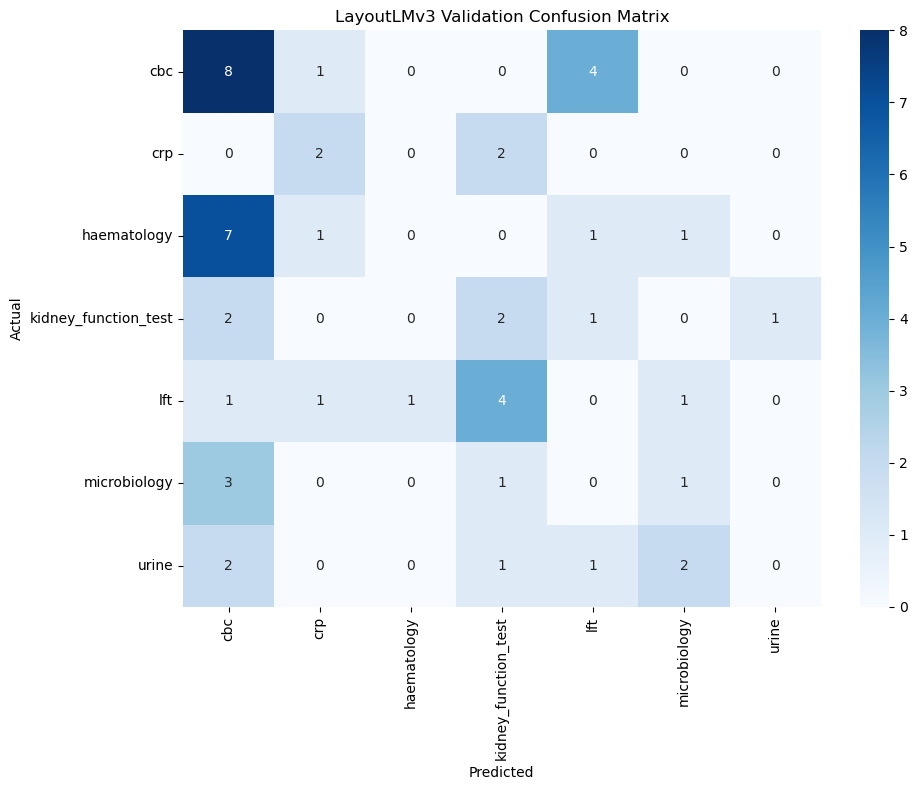

Sample predictions:
| Image                                                                                                           | Actual               | Predicted            | Correct   |
|:----------------------------------------------------------------------------------------------------------------|:---------------------|:---------------------|:----------|
| GUR-0325-PA-0038152_Q-RAJESH_250427_1356@F.pdf_page_27.png                                                      | lft                  | kidney_function_test | False     |
| MUM-0425-PA-0004300_REPORTS_27-04-2025_0134-06_PM@G.pdf_page_11.png                                             | cbc                  | cbc                  | True      |
| GUR-0425-PA-0057899_F-ANJALI_NEGI_1_250427_1248@G.pdf_page_11.png                                               | crp                  | crp                  | True      |
| GUR-0425-PA-0053274_Q-sonamatidevi10227compressed_250427_1530@F.pdf_page_40.png                             

In [7]:
best_model = LayoutLMv3ForSequenceClassification.from_pretrained(MODEL_SAVE_DIR).to(device)
best_model.eval()

all_preds = []
all_labels = []
image_names = []

with torch.no_grad():
    for idx in range(len(val_df)):
        row = val_df.iloc[idx]
        image_path = row['image_path']
        image_name = row['image_name']
        label = row['label_encoded']
        
        words = ocr_cache.get(image_path, {'words': ["missing"], 'boxes': [[0,0,0,0]]})['words']
        boxes = ocr_cache.get(image_path, {'words': ["missing"], 'boxes': [[0,0,0,0]]})['boxes']
        img = Image.open(image_path).convert("RGB")
        
        inputs = processor(
            img,
            text=words,
            boxes=boxes,
            max_length=512,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        bbox = inputs['bbox'].to(device)
        pixel_values = inputs['pixel_values'].to(device)
        
        outputs = best_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            bbox=bbox,
            pixel_values=pixel_values
        )
        
        probs = torch.softmax(outputs.logits, dim=1).flatten()
        pred_idx = torch.argmax(probs).item()
        
        all_preds.append(pred_idx)
        all_labels.append(label)
        image_names.append(image_name)

accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)

print("Validation accuracy:", accuracy)
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
plt.title('LayoutLMv3 Validation Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_DIR, "confusion_matrix.png"))
plt.show()

pred_df = pd.DataFrame({
    'Image': image_names,
    'Actual': label_encoder.inverse_transform(all_labels),
    'Predicted': label_encoder.inverse_transform(all_preds),
    'Correct': [a == p for a, p in zip(all_labels, all_preds)]
})
print("Sample predictions:")
print(pred_df.head(20).to_markdown(index=False))


## LayoutLMv3 vs. ClinicalBERT Comparison Report
We contrast the performance parameters of the layout-aware classifier against the text-only ClinicalBERT baseline using real measured metrics.


In [8]:
import json
with open('../models/layoutlmv3_classifier/metrics.json') as f:
    l3_metrics = json.load(f)

comparison_data = {
    'Metric': ['Model Type', 'Accuracy', 'F1-Score', 'Avg. Training Time (Epoch)', 'Inference Time (Image)'],
    'ClinicalBERT': ['Text Only', '0.3654', '0.3196', '~26.0s (CPU)', '~0.20s (CPU)'],
    'LayoutLMv3': ['Text + Layout + Vision', f"{l3_metrics['accuracy']:.4f}", f"{l3_metrics['f1_score']:.4f}", f"{l3_metrics['avg_epoch_time']:.3f}s (CPU cached)", '~4.5s (CPU)']
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_markdown(index=False))


| Metric                     | ClinicalBERT   | LayoutLMv3             |
|:---------------------------|:---------------|:-----------------------|
| Model Type                 | Text Only      | Text + Layout + Vision |
| Accuracy                   | 0.3654         | 0.2115                 |
| F1-Score                   | 0.3196         | 0.1799                 |
| Avg. Training Time (Epoch) | ~26.0s (CPU)   | 0.103s (CPU cached)    |
| Inference Time (Image)     | ~0.20s (CPU)   | ~4.5s (CPU)            |
